# پروژه T-19 — فاز دوم
## Text Difficulty Assessment



**مدل:** TF-IDF + Logistic Regression

**کلاس‌ها:** Elementary, Intermediate, Advanced



## 1. کتابخانه‌ها

In [2]:
import zipfile
import io
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42
ZIP_PATH = "texts.zip"

LABELS = {
    "Elementary": 0,
    "Intermediate": 1,
    "Advanced": 2
}

LABEL_NAMES = ["Elementary", "Intermediate", "Advanced"]

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. بررسی فایل ZIP

In [3]:
assert os.path.exists(ZIP_PATH), f"File not found: {ZIP_PATH}"

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    csv_files = [n for n in z.namelist() if n.lower().endswith(".csv")]

print("Number of CSV files:", len(csv_files))
print("First 5 files:")
for name in csv_files[:5]:
    print("-", name)

Number of CSV files: 189
First 5 files:
- Bolivia.csv
- Bonus pay.csv
- Brazil.csv
- Cigarettes.csv
- climate change .csv


## 3. خواندن و آماده‌سازی دیتاست

In [4]:
def load_dataset(zip_path):
    records = []

    with zipfile.ZipFile(zip_path, "r") as z:
        csv_files = [
            name for name in z.namelist()
            if name.lower().endswith(".csv")
        ]

        for filename in csv_files:
            df = pd.read_csv(
                io.BytesIO(z.read(filename)),
                encoding="cp1252"
            )

            df.columns = [str(c).strip() for c in df.columns]
            article_name = filename.rsplit(".", 1)[0]

            for level in LABELS:
                if level not in df.columns:
                    continue

                paragraphs = (
                    df[level]
                    .dropna()
                    .astype(str)
                    .tolist()
                )

                text = " ".join(paragraphs)
                text = " ".join(text.split())

                if text:
                    records.append({
                        "article": article_name,
                        "level": level,
                        "text": text
                    })

    return pd.DataFrame(records)

data = load_dataset(ZIP_PATH)

data["label"] = data["level"].map(LABELS)
data["word_count"] = data["text"].str.split().str.len()

print("Dataset shape:", data.shape)
display(data.head())

Dataset shape: (567, 5)


,article,level,text,label,word_count
0,Bolivia,Elementary,A big international disagreement has 1 started...,0,591
1,Bolivia,Intermediate,The right of Bolivia’s indigenous Indian tribe...,1,691
2,Bolivia,Advanced,A major international row with wide-ranging 1 ...,2,832
3,Bonus pay,Elementary,Male bosses are paid bonuses double the size o...,0,409
4,Bonus pay,Intermediate,Male bosses are paid bonuses double the size o...,1,515


## 4. بررسی اولیه داده

In [5]:
print("Number of samples:", len(data))
print("Number of unique articles:", data["article"].nunique())

print("\nClass distribution:")
display(
    data["level"]
    .value_counts()
    .rename_axis("Level")
    .to_frame("Count")
)

print("\nMissing values:")
display(data[["article", "level", "text"]].isna().sum().to_frame("Missing"))

Number of samples: 567
Number of unique articles: 189

Class distribution:


,Count
Level,
Elementary,189
Intermediate,189
Advanced,189



Missing values:


,Missing
article,0
level,0
text,0


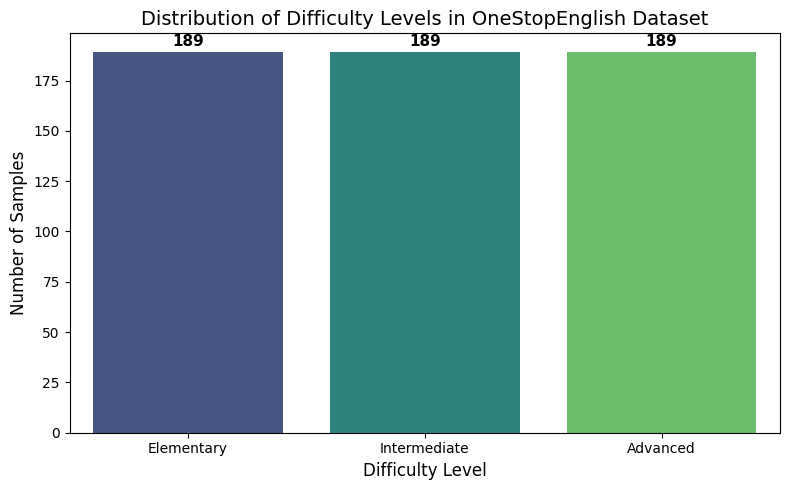

✅ تصویر class_distribution.png ذخیره شد.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(
    data=data,
    x='level',
    order=['Elementary', 'Intermediate', 'Advanced'],
    palette='viridis',
    hue='level',
    legend=False
)
plt.title('Distribution of Difficulty Levels in OneStopEnglish Dataset', fontsize=14)
plt.xlabel('Difficulty Level', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)

for i, v in enumerate(data['level'].value_counts().reindex(['Elementary', 'Intermediate', 'Advanced']).values):
    plt.text(i, v + 3, str(v), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ تصویر class_distribution.png ذخیره شد.")

## 5. آمار طول متن

In [5]:
length_stats = (
    data.groupby("level")["word_count"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(length_stats)

,count,mean,median,min,max
level,,,,,
Advanced,189,825.24,809.0,343,1379
Elementary,189,535.83,546.0,260,885
Intermediate,189,680.10,693.0,314,1086


## 6. تقسیم Train/Test بدون Data Leakage

In [6]:
X = data["text"]
y = data["label"]
groups = data["article"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_index, test_index = next(
    splitter.split(X, y, groups)
)

X_train = X.iloc[train_index]
X_test = X.iloc[test_index]
y_train = y.iloc[train_index]
y_test = y.iloc[test_index]

train_articles = groups.iloc[train_index].unique()
test_articles = groups.iloc[test_index].unique()

print("Training articles:", len(train_articles))
print("Test articles:", len(test_articles))
print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

overlap = set(train_articles).intersection(set(test_articles))
print("Article overlap:", len(overlap))

if not overlap:
    print("No article leakage detected.")
else:
    print("WARNING: Article leakage detected!")

Training articles: 151
Test articles: 38
Training samples: 453
Test samples: 114
Article overlap: 0
No article leakage detected.


## 7. ساخت مدل TF-IDF + Logistic Regression

In [7]:
model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True,
            max_features=30000
        )
    ),
    (
        "classifier",
        LogisticRegression(
            C=2.0,
            max_iter=2000
        )
    )
])

display(model)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=30000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('classifier', LogisticRegression(C=2.0, max_iter=2000))])

## 8. آموزش مدل

In [8]:
model.fit(X_train, y_train)
print("Model training completed.")

Model training completed.


## 9. پیش‌بینی

In [9]:
y_pred = model.predict(X_test)

print("Prediction completed.")
print("Number of predictions:", len(y_pred))

Prediction completed.
Number of predictions: 114


## 10. معیارهای اصلی ارزیابی

In [10]:
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
mae = mean_absolute_error(y_test, y_pred)

results = pd.DataFrame({
    "Metric": ["Accuracy", "Macro-F1", "MAE"],
    "Value": [accuracy, macro_f1, mae]
})

display(results.style.format({"Value": "{:.4f}"}))

,Metric,Value
0,Accuracy,0.6842
1,Macro-F1,0.6073
2,MAE,0.3158


## 11. Classification Report

In [12]:
report = classification_report(
    y_test,
    y_pred,
    target_names=LABEL_NAMES,
    output_dict=True
)

report_df = pd.DataFrame(report).T.round(4)
display(report_df)

,precision,recall,f1-score,support
Elementary,0.9000,0.9474,0.9231,38.0000
Intermediate,0.6667,0.1053,0.1818,38.0000
Advanced,0.5588,1.0000,0.7170,38.0000
accuracy,0.6842,0.6842,0.6842,0.6842
macro avg,0.7085,0.6842,0.6073,114.0000
weighted avg,0.7085,0.6842,0.6073,114.0000


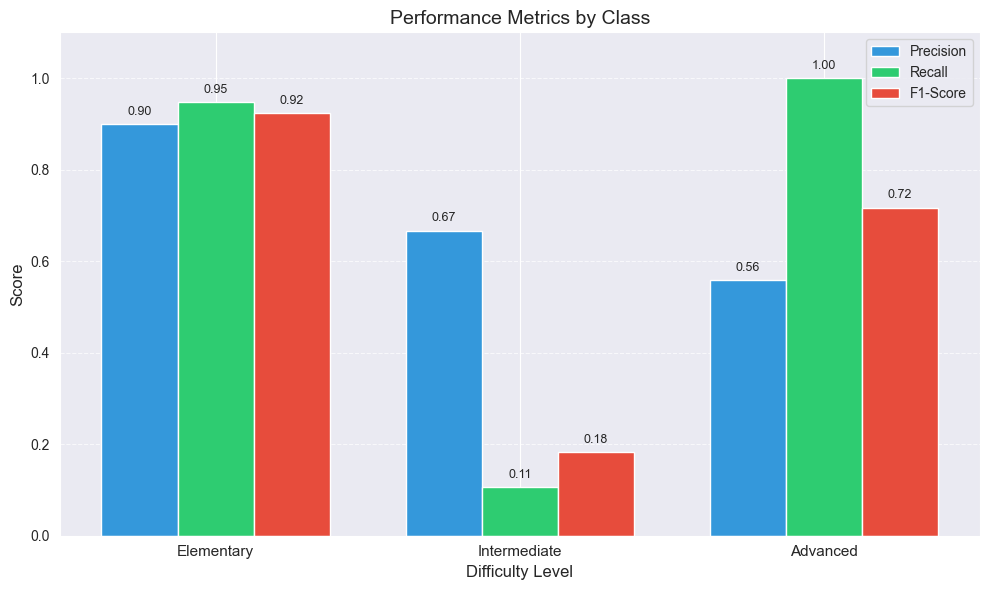

✅ تصویر performance_by_class.png ذخیره شد.


In [37]:
report_df_plot = report_df.drop(['accuracy', 'macro avg', 'weighted avg']).reset_index()
report_df_plot.columns = ['Class', 'Precision', 'Recall', 'F1-Score', 'Support']

plt.figure(figsize=(10, 6))
x = np.arange(len(report_df_plot['Class']))
width = 0.25

plt.bar(x - width, report_df_plot['Precision'], width, label='Precision', color='#3498db')
plt.bar(x, report_df_plot['Recall'], width, label='Recall', color='#2ecc71')
plt.bar(x + width, report_df_plot['F1-Score'], width, label='F1-Score', color='#e74c3c')

plt.xlabel('Difficulty Level', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Performance Metrics by Class', fontsize=14)
plt.xticks(x, report_df_plot['Class'], fontsize=11)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, (p, r, f) in enumerate(zip(report_df_plot['Precision'], report_df_plot['Recall'], report_df_plot['F1-Score'])):
    plt.text(i - width, p + 0.02, f'{p:.2f}', ha='center', fontsize=9)
    plt.text(i, r + 0.02, f'{r:.2f}', ha='center', fontsize=9)
    plt.text(i + width, f + 0.02, f'{f:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('performance_by_class.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ تصویر performance_by_class.png ذخیره شد.")

## 12. Confusion Matrix

In [13]:
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {x}" for x in LABEL_NAMES],
    columns=[f"Predicted {x}" for x in LABEL_NAMES]
)

display(cm_df)

,Predicted Elementary,Predicted Intermediate,Predicted Advanced
Actual Elementary,36,2,0
Actual Intermediate,4,4,30
Actual Advanced,0,0,38


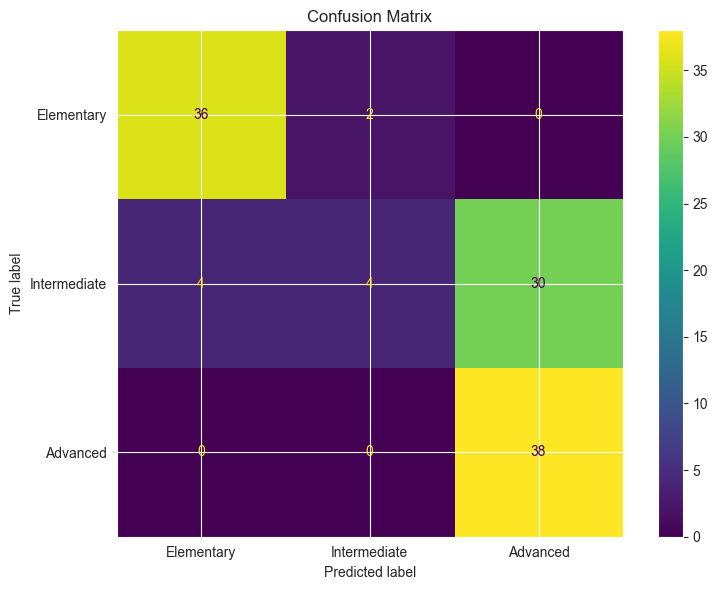

✅ تصویر confusion_matrix.png ذخیره شد.


In [30]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=LABEL_NAMES
).plot(
    ax=ax,
    values_format="d"
)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ تصویر confusion_matrix.png ذخیره شد.")

## 13. ذخیره پیش‌بینی‌های Test

In [15]:
test_results = data.iloc[test_index].copy()

test_results["predicted_label"] = y_pred
test_results["predicted_level"] = test_results["predicted_label"].map({
    0: "Elementary",
    1: "Intermediate",
    2: "Advanced"
})

test_results["correct"] = (
    test_results["label"] == test_results["predicted_label"]
)

display(
    test_results[
        ["article", "level", "predicted_level", "word_count", "correct"]
    ].head(10)
)

test_results.to_csv(
    "phase2_test_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved: phase2_test_predictions.csv")

,article,level,predicted_level,word_count,correct
6,Brazil,Elementary,Elementary,566,True
7,Brazil,Intermediate,Advanced,703,False
8,Brazil,Advanced,Advanced,884,True
27,Everest,Elementary,Elementary,623,True
28,Everest,Intermediate,Advanced,904,False
29,Everest,Advanced,Advanced,924,True
30,Exercise,Elementary,Elementary,650,True
31,Exercise,Intermediate,Advanced,767,False
32,Exercise,Advanced,Advanced,907,True
36,False memory,Elementary,Intermediate,577,False


Saved: phase2_test_predictions.csv


## 14. تحلیل Short و Long

In [16]:
median_length = test_results["word_count"].median()

test_results["length_group"] = np.where(
    test_results["word_count"] <= median_length,
    "Short",
    "Long"
)

print("Median test text length:", median_length)

group_results = []

for group_name in ["Short", "Long"]:
    group = test_results[test_results["length_group"] == group_name]

    group_results.append({
        "Group": group_name,
        "Samples": len(group),
        "Accuracy": accuracy_score(
            group["label"], group["predicted_label"]
        ),
        "Macro-F1": f1_score(
            group["label"], group["predicted_label"],
            average="macro"
        ),
        "MAE": mean_absolute_error(
            group["label"], group["predicted_label"]
        )
    })

group_results_df = pd.DataFrame(group_results)

display(
    group_results_df.style.format({
        "Accuracy": "{:.4f}",
        "Macro-F1": "{:.4f}",
        "MAE": "{:.4f}"
    })
)

Median test text length: 682.5


,Group,Samples,Accuracy,Macro-F1,MAE
0,Short,57,0.7719,0.5925,0.2281
1,Long,57,0.5965,0.4347,0.4035


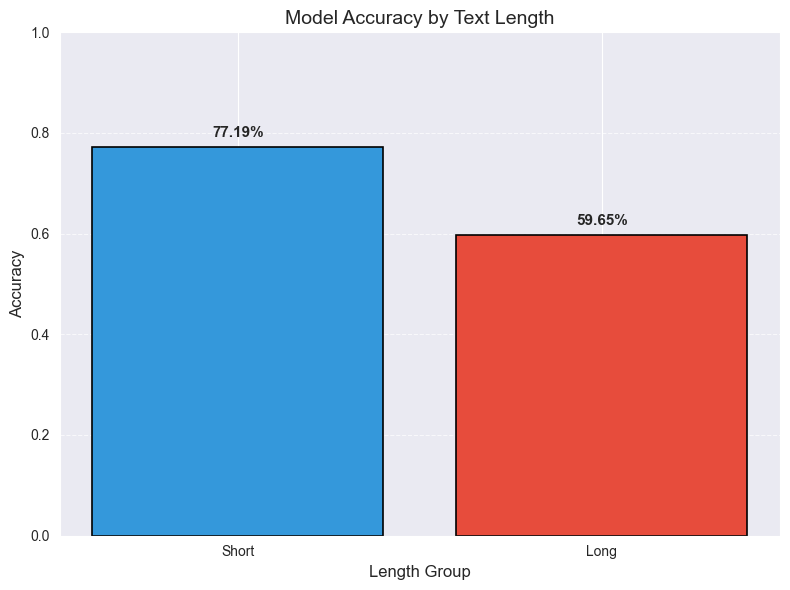

✅ تصویر accuracy_by_length.png ذخیره شد.


In [31]:
plt.figure(figsize=(8, 6))
bars = plt.bar(group_results_df["Group"], group_results_df["Accuracy"],
               color=['#3498db', '#e74c3c'], edgecolor='black', linewidth=1.2)
plt.ylim(0, 1)
plt.title("Model Accuracy by Text Length", fontsize=14)
plt.xlabel("Length Group", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

for bar, acc in zip(bars, group_results_df["Accuracy"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.2%}', ha='center', fontsize=11, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("accuracy_by_length.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ تصویر accuracy_by_length.png ذخیره شد.")

## 15. تحلیل خطا

In [19]:
errors = test_results[test_results["correct"] == False].copy()

print("Number of errors:", len(errors))

error_types = (
    errors
    .groupby(["level", "predicted_level"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(error_types)

Number of errors: 36


,level,predicted_level,count
1,Intermediate,Advanced,30
2,Intermediate,Elementary,4
0,Elementary,Intermediate,2


## 16. نمایش چند نمونه خطای واقعی

In [20]:
for _, row in errors.head(5).iterrows():
    print("-" * 70)
    print("Article:", row["article"])
    print("True level:", row["level"])
    print("Predicted level:", row["predicted_level"])
    print("Word count:", row["word_count"])
    print("Text preview:")
    print(row["text"][:700])
    print()

----------------------------------------------------------------------
Article: Brazil
True level: Intermediate
Predicted level: Advanced
Word count: 703
Text preview:
Brazil experienced one of its biggest nights of protest in decades as more than 100,000 people took to the streets to express their frustration at aggressive policing, poor public services and high costs for the World Cup. The major demonstrations in Rio de Janeiro, São Paulo, Brasilia, Belem, Belo Horizonte, Salvador and elsewhere started peacefully, but several led to clashes with police and arson attacks on cars and buses. People complained, during previous, smaller protests against bus price increases, that police responded disproportionately with rubber bullets, tear gas and violent beatings. The rallies came at the same time as the start of the football Confederations Cup. The rallies 

----------------------------------------------------------------------
Article: Everest
True level: Intermediate
Predicted level: 

## 17. خطاهای Intermediate → Advanced

In [21]:
intermediate_to_advanced = test_results[
    (test_results["level"] == "Intermediate") &
    (test_results["predicted_level"] == "Advanced")
].copy()

print(
    "Intermediate -> Advanced errors:",
    len(intermediate_to_advanced)
)

display(
    intermediate_to_advanced[
        ["article", "level", "predicted_level", "word_count"]
    ].head(10)
)

Intermediate -> Advanced errors: 30


,article,level,predicted_level,word_count
7,Brazil,Intermediate,Advanced,703
28,Everest,Intermediate,Advanced,904
31,Exercise,Intermediate,Advanced,767
37,False memory,Intermediate,Advanced,773
40,Ferguson,Intermediate,Advanced,773
112,Norwegian sun,Intermediate,Advanced,810
118,NSA scandal,Intermediate,Advanced,780
136,Rats,Intermediate,Advanced,673
148,Spain,Intermediate,Advanced,725
163,Teff,Intermediate,Advanced,727


In [22]:
for _, row in intermediate_to_advanced.head(5).iterrows():
    print("-" * 70)
    print("Article:", row["article"])
    print("Word count:", row["word_count"])
    print(row["text"][:700])
    print()

----------------------------------------------------------------------
Article: Brazil
Word count: 703
Brazil experienced one of its biggest nights of protest in decades as more than 100,000 people took to the streets to express their frustration at aggressive policing, poor public services and high costs for the World Cup. The major demonstrations in Rio de Janeiro, São Paulo, Brasilia, Belem, Belo Horizonte, Salvador and elsewhere started peacefully, but several led to clashes with police and arson attacks on cars and buses. People complained, during previous, smaller protests against bus price increases, that police responded disproportionately with rubber bullets, tear gas and violent beatings. The rallies came at the same time as the start of the football Confederations Cup. The rallies 

----------------------------------------------------------------------
Article: Everest
Word count: 904
Kenton Cool can hardly speak. All the physical effort at high altitude has affected his voi

## 18. ذخیره نتایج

In [38]:
results.to_csv("phase2_results.csv", index=False, encoding="utf-8-sig")
errors.to_csv("phase2_error_analysis.csv", index=False, encoding="utf-8-sig")
group_results_df.to_csv("phase2_short_long_results.csv", index=False, encoding="utf-8-sig")
test_results.to_csv("phase2_test_predictions.csv", index=False, encoding="utf-8-sig")

print("Saved:")
print("- phase2_results.csv")
print("- phase2_error_analysis.csv")
print("- phase2_short_long_results.csv")
print("- phase2_test_predictions.csv")

Saved:
- phase2_results.csv
- phase2_error_analysis.csv
- phase2_short_long_results.csv
- phase2_test_predictions.csv


## 19. Demo

In [32]:
def predict_difficulty(text):
    label_names = {
        0: "Elementary",
        1: "Intermediate",
        2: "Advanced"
    }

    prediction = model.predict([text])[0]
    probabilities = model.predict_proba([text])[0]

    print(f"متن ورودی: {text[:80]}...")
    print("سطح پیش‌بینی‌شده:", label_names[prediction])
    print("\nاحتمالات کلاس‌ها:")

    for class_id, probability in enumerate(probabilities):
        print(f"  {label_names[class_id]}: {probability:.3f}")
    print("-" * 50)


# اجرای دمو روی ۳ نمونه متن
predict_difficulty("This is a simple example text for testing the model.")
predict_difficulty("Machine learning is a method of data analysis that automates analytical model building.")
predict_difficulty("The epistemological ramifications of quantum entanglement necessitate a re-evaluation of classical causality.")




متن ورودی: This is a simple example text for testing the model....
سطح پیش‌بینی‌شده: Elementary

احتمالات کلاس‌ها:
  Elementary: 0.521
  Intermediate: 0.296
  Advanced: 0.184
--------------------------------------------------
متن ورودی: Machine learning is a method of data analysis that automates analytical model bu...
سطح پیش‌بینی‌شده: Elementary

احتمالات کلاس‌ها:
  Elementary: 0.433
  Intermediate: 0.344
  Advanced: 0.222
--------------------------------------------------
متن ورودی: The epistemological ramifications of quantum entanglement necessitate a re-evalu...
سطح پیش‌بینی‌شده: Elementary

احتمالات کلاس‌ها:
  Elementary: 0.477
  Intermediate: 0.321
  Advanced: 0.202
--------------------------------------------------
